# Area of Interest | Network | Isochrones
### This notebook contains an example of using accessX to prepare the area of analysis, analyse the street network, and estimate walking isochrones for Amsterdam, Athens, and Milan.

In [ ]:
from pathlib import Path

import accessx as acx
import osmnx as ox
import os
import matplotlib.pyplot as plt

### Load Area of Interest

In [ ]:
# (1) Use OSMnx to geocode a city's boundaries and get its geometry as a GeoDataFrame
#This step can be done reading the actual city boundary from a file, 
# but this is a quick way to get it for demonstration purposes.

epsg_ams = 28992
epsg_ath = 2100
epsg_mil = 32632

data_path = Path("../data/case_studies/isochrones")
street_network_path = data_path / "street_network"
results_path = data_path / "results"

for folder in [data_path, street_network_path, results_path]:
    folder.mkdir(parents=True, exist_ok=True)

gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
gdf_ath = ox.geocode_to_gdf("Municipality of Athens, Greece")
gdf_mil = ox.geocode_to_gdf("Milan, Italy")

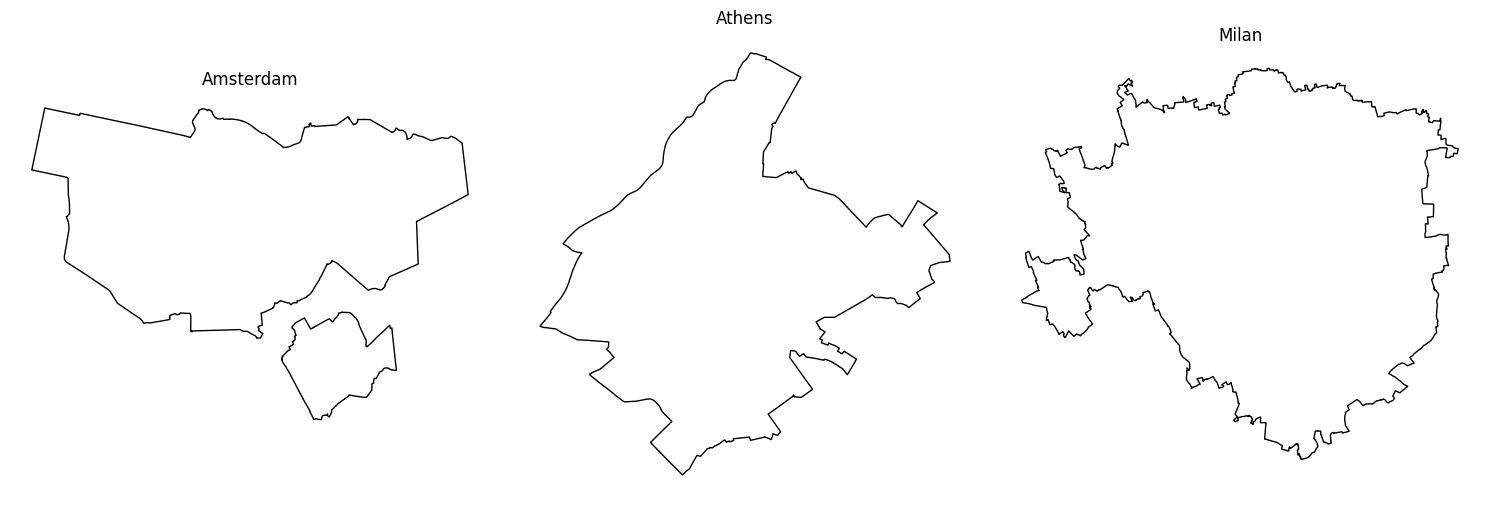

In [3]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [gdf_ams, gdf_ath, gdf_mil]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Make Hex Grid

In [4]:
ams_hex = acx.make_hex_grid(aoi=gdf_ams, resolution=9)    
ath_hex = acx.make_hex_grid(aoi=gdf_ath, resolution=9)    
mil_hex = acx.make_hex_grid(aoi=gdf_mil , resolution=9)    

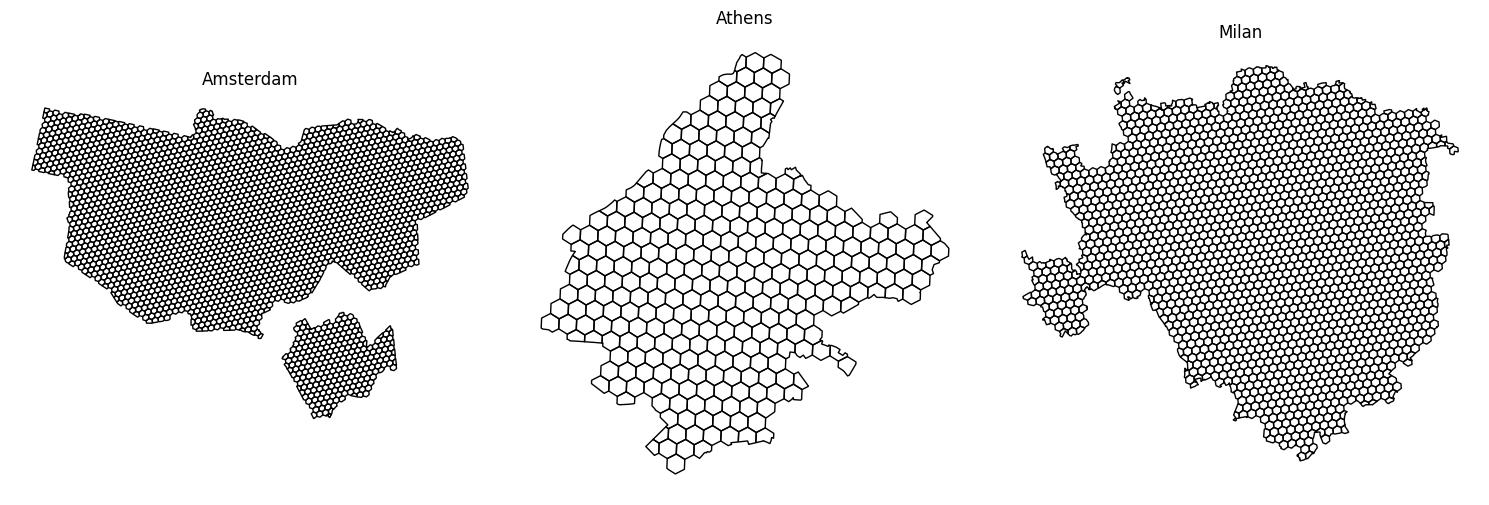

In [5]:
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

gdfs = [ams_hex, ath_hex, mil_hex]
titles = ["Amsterdam", "Athens", "Milan"]

for ax, gdf, title in zip(axes, gdfs, titles):
    gdf.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Download Street Network

In [ ]:
cities = [
    {"name": "amsterdam", "aoi": gdf_ams, "epsg": epsg_ams},
    {"name": "athens", "aoi": gdf_ath, "epsg": epsg_ath},
    {"name": "milan", "aoi": gdf_mil, "epsg": epsg_mil},
]

buffer = 1000
graphs = {}

for city in cities:
    G_proj = acx.build_network(
        AOI=city["aoi"],
        city_epsg=city["epsg"],
        buffer_m=buffer,
        network_type="walk",
        simplify=False,
        retain_all=True,
        show_progress=True,
    )

    acx.save_graph(
        G_proj,
        out_dir=street_network_path,
        base_name=f"original_graph_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )
    graphs[city["name"]] = G_proj


Building street network:   0%|          | 0/4 [00:00<?, ?step/s]

Building street network:   0%|          | 0/4 [00:00<?, ?step/s]

Building street network:   0%|          | 0/4 [00:00<?, ?step/s]

### Add travel cost to the network
Add constant speed

In [ ]:
# Read the graph 

constant_speed_kmh = 4.5
cities = [
    {"name": "amsterdam", "epsg": epsg_ams},
    {"name": "athens", "epsg": epsg_ath},
    {"name": "milan", "epsg": epsg_mil},
]

graphs_with_speeds = {}

for city in cities:
    G_proj = acx.load_graph(
        nodes_path=street_network_path / f"original_graph_{city['name']}_nodes_OSM.geojson",
        edges_path=street_network_path / f"original_graph_{city['name']}_edges_OSM.geojson",
        crs=city["epsg"]
    )

    G_proj = acx.add_time_cost_constant_speed(
        G_proj,
        speed_kmh=constant_speed_kmh,
        cost_col="avg_time",
        show_progress=True
    )
    acx.save_graph(
        G_proj,
        out_dir=street_network_path,
        base_name=f"graph_with_cost_{city['name']}",
        save_nodes=True,
        save_edges=True,
    )

    graphs_with_speeds[city["name"]] = G_proj


Adding avg_time:   0%|          | 0/596704 [00:00<?, ?edge/s]

Adding avg_time:   0%|          | 0/206668 [00:00<?, ?edge/s]

Adding avg_time:   0%|          | 0/865282 [00:00<?, ?edge/s]

## Load network and Plot

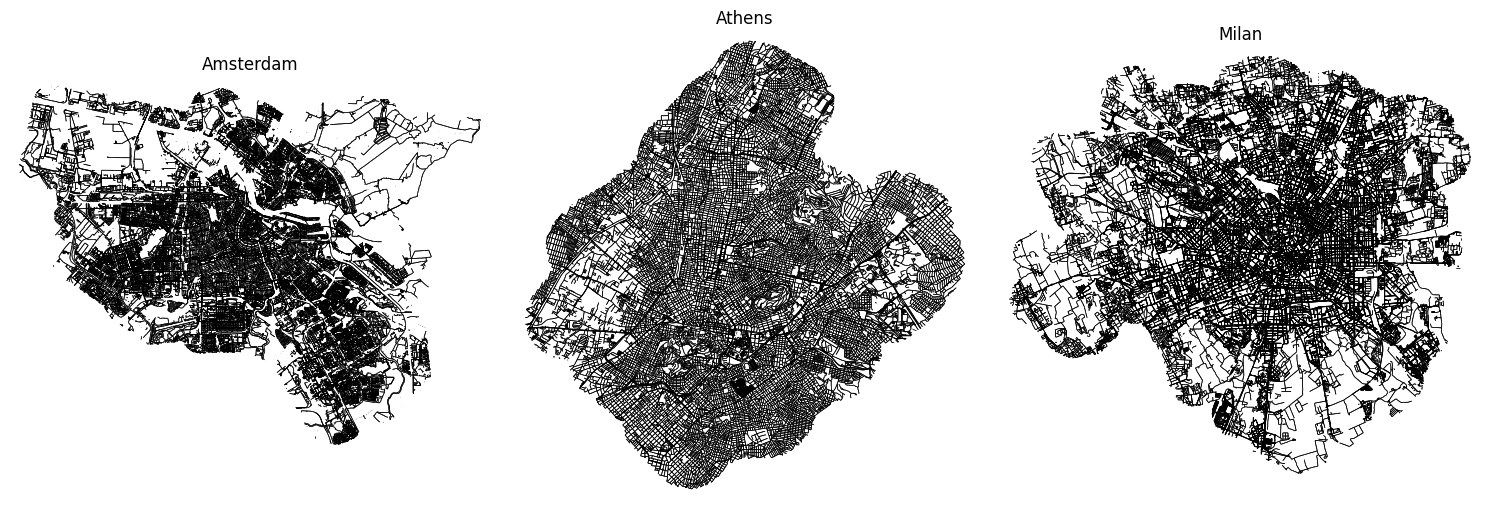

In [ ]:
# graphs_with_speeds = {}

# # read graphs
# for city in cities:
#     G_proj = acx.load_graph(
#         nodes_path=street_network_path / f"graph_with_cost_{city['name']}_nodes_OSM.geojson",
#         edges_path=street_network_path / f"graph_with_cost_{city['name']}_edges_OSM.geojson",
#         crs=city["epsg"]
#     )
#     graphs_with_speeds[city["name"]] = G_proj

# plot graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    ox.plot_graph(
        graphs_with_speeds[city_name],
        ax=ax,
        node_size=0,
        edge_color="black",
        edge_linewidth=0.5,
        show=False,
        close=False
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Estimate Isochrones
For this example we estimate isochrones representing 5, 10, and 15-minutes walk, for 5 locations per city.

In [ ]:
gdfs_iso = {}

city_data = [
    {"name": "amsterdam", "hex": ams_hex, "epsg": epsg_ams},
    {"name": "athens", "hex": ath_hex, "epsg": epsg_ath},
    {"name": "milan", "hex": mil_hex, "epsg": epsg_mil},
]

for city in city_data:

    gdf_iso = acx.calculate_isochrones(
        graphs_with_speeds[city["name"]],
    city["hex"].sample(n=5, random_state=42).to_crs(city["epsg"]),
        max_cost=15,
        interval_size=5,
        cost_attr="avg_time",
        city_epsg=city["epsg"],
        max_distance=200,
        method="edges",
        # n_jobs=os.cpu_count() - 1,
        show_progress=True,
        edge_buff=25,
        infill=True,
        base_name=f"isochrones_{city['name']}",
        save_dir=results_path,
    )

    gdfs_iso[city["name"]] = gdf_iso

Calculating isochrones:   0%|          | 0/5 [00:00<?, ?hex/s]

Calculating isochrones:   0%|          | 0/5 [00:00<?, ?hex/s]

Calculating isochrones:   0%|          | 0/5 [00:00<?, ?hex/s]

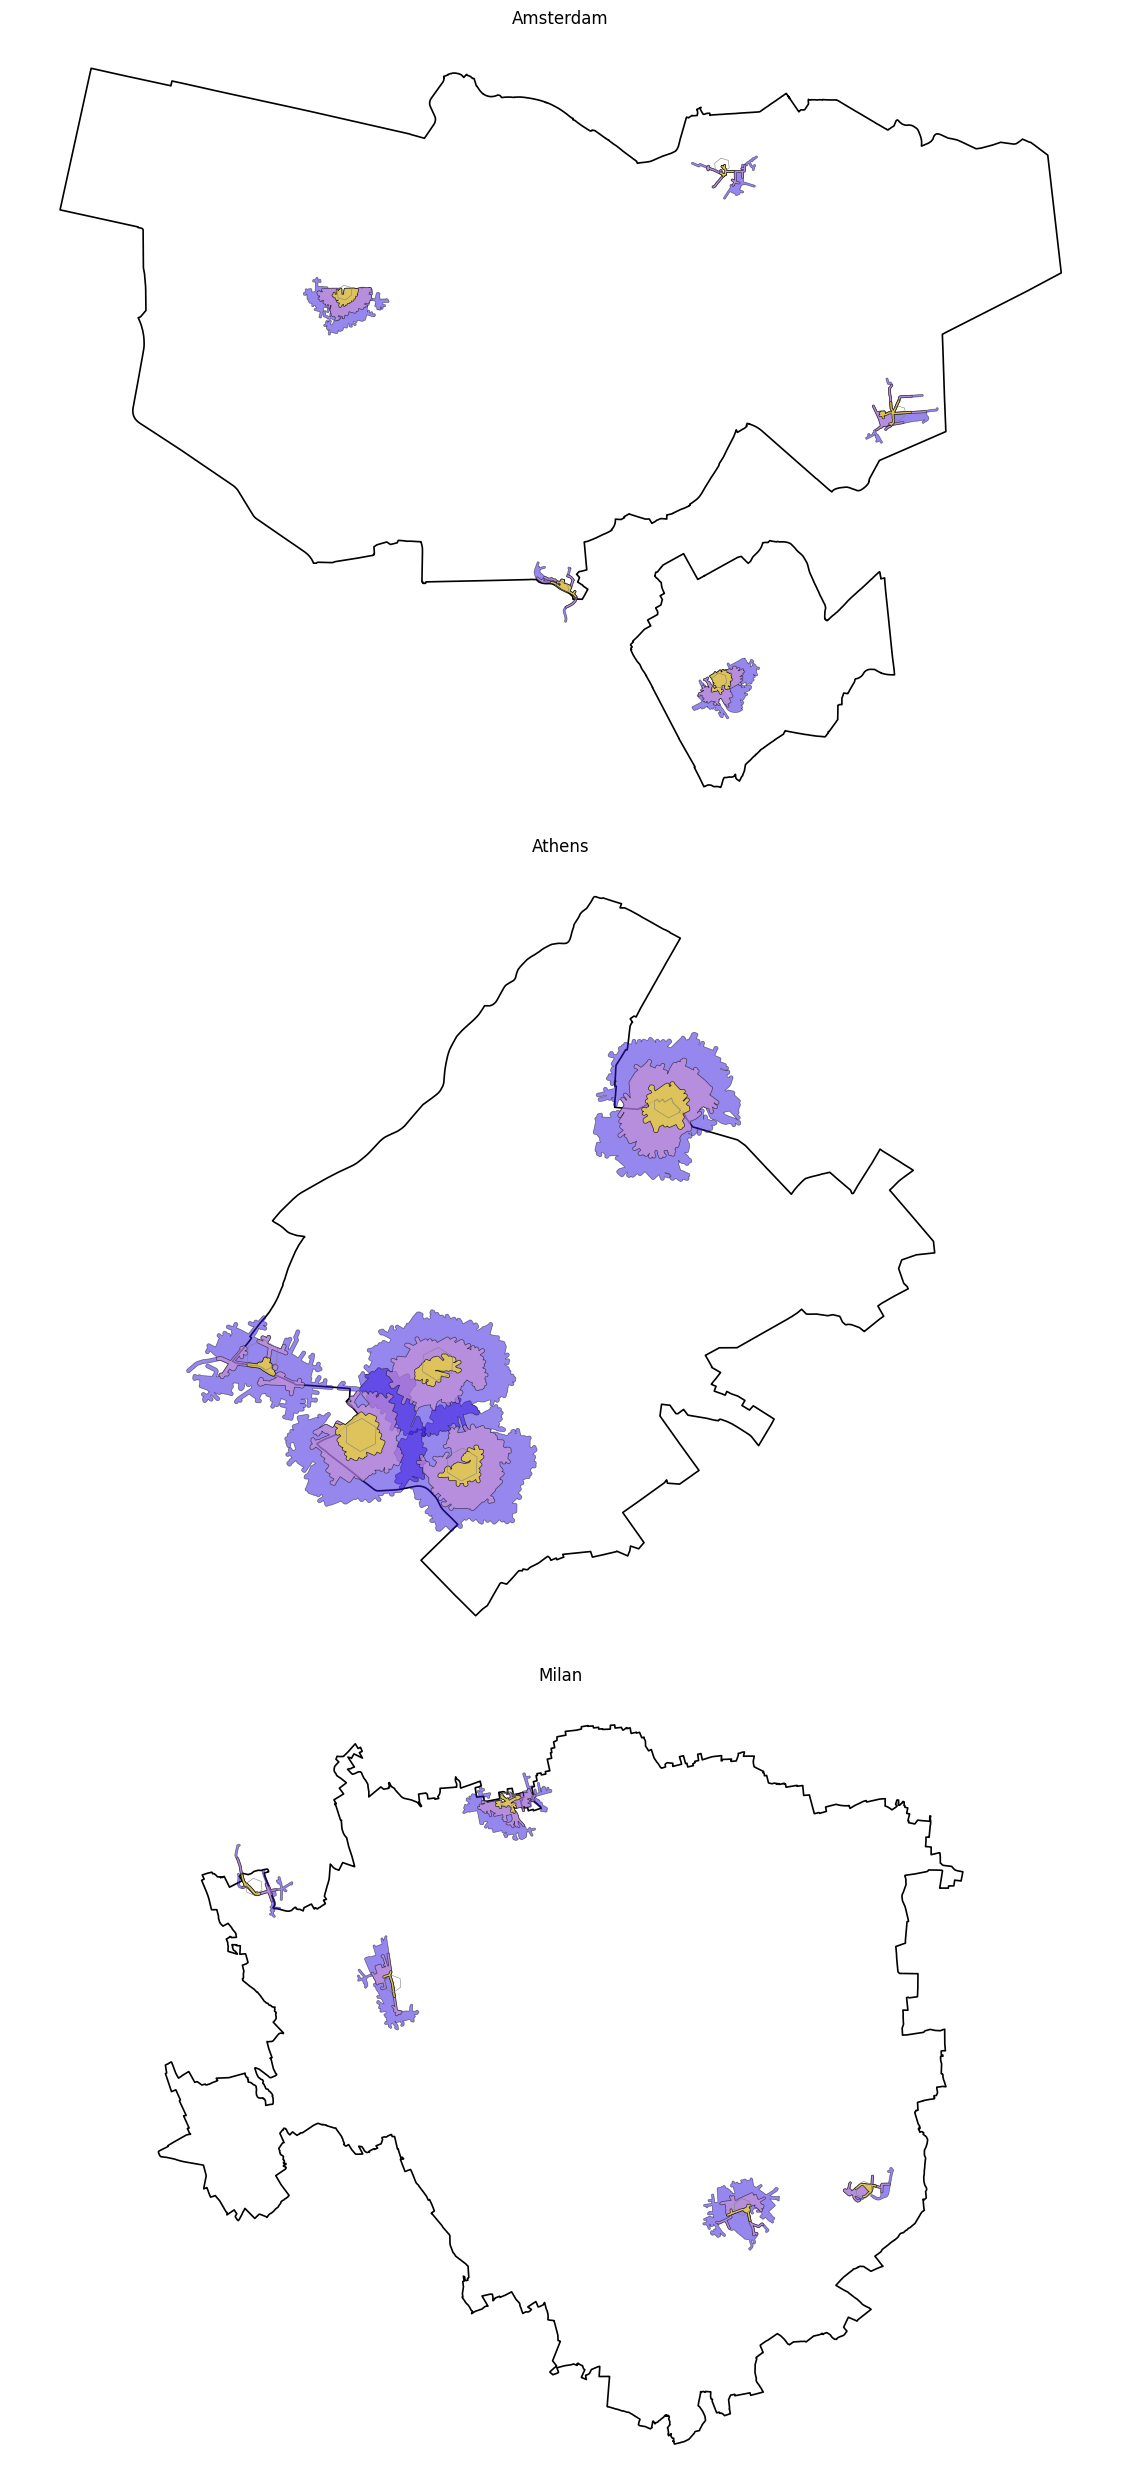

In [25]:
import matplotlib.pyplot as plt
import geopandas as gpd
import osmnx as ox

# city boundaries
area_gdfs = {
    "amsterdam": gdf_ams,
    "athens": gdf_ath,
    "milan": gdf_mil,
}

fig, axes = plt.subplots(3, 1, figsize=(15, 25))

titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

for ax, city_name, title in zip(axes, city_names, titles):
    gdf = gdfs_iso[city_name]

    # reproject city boundary to match isochrone CRS
    area = area_gdfs[city_name].to_crs(gdf.crs)

    # plot city boundary first
    area.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.2)

    # 15 min in the back
    gpd.GeoSeries(gdf["geom_avg_time_15"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#2f10e0", edgecolor="black", linewidth=0.5, alpha=0.5
    )

    # 10 min in the middle
    gpd.GeoSeries(gdf["geom_avg_time_10"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#CE94D3", edgecolor="black", linewidth=0.5, alpha=0.6
    )

    # 5 min on top
    gpd.GeoSeries(gdf["geom_avg_time_5"], crs=gdf.crs).dropna().plot(
        ax=ax, color="#E8D13C", edgecolor="black", linewidth=0.5, alpha=0.8
    )

    # optional: show the sampled hexes too
    gdf.plot(ax=ax, facecolor="none", edgecolor="grey", linewidth=0.4)

    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

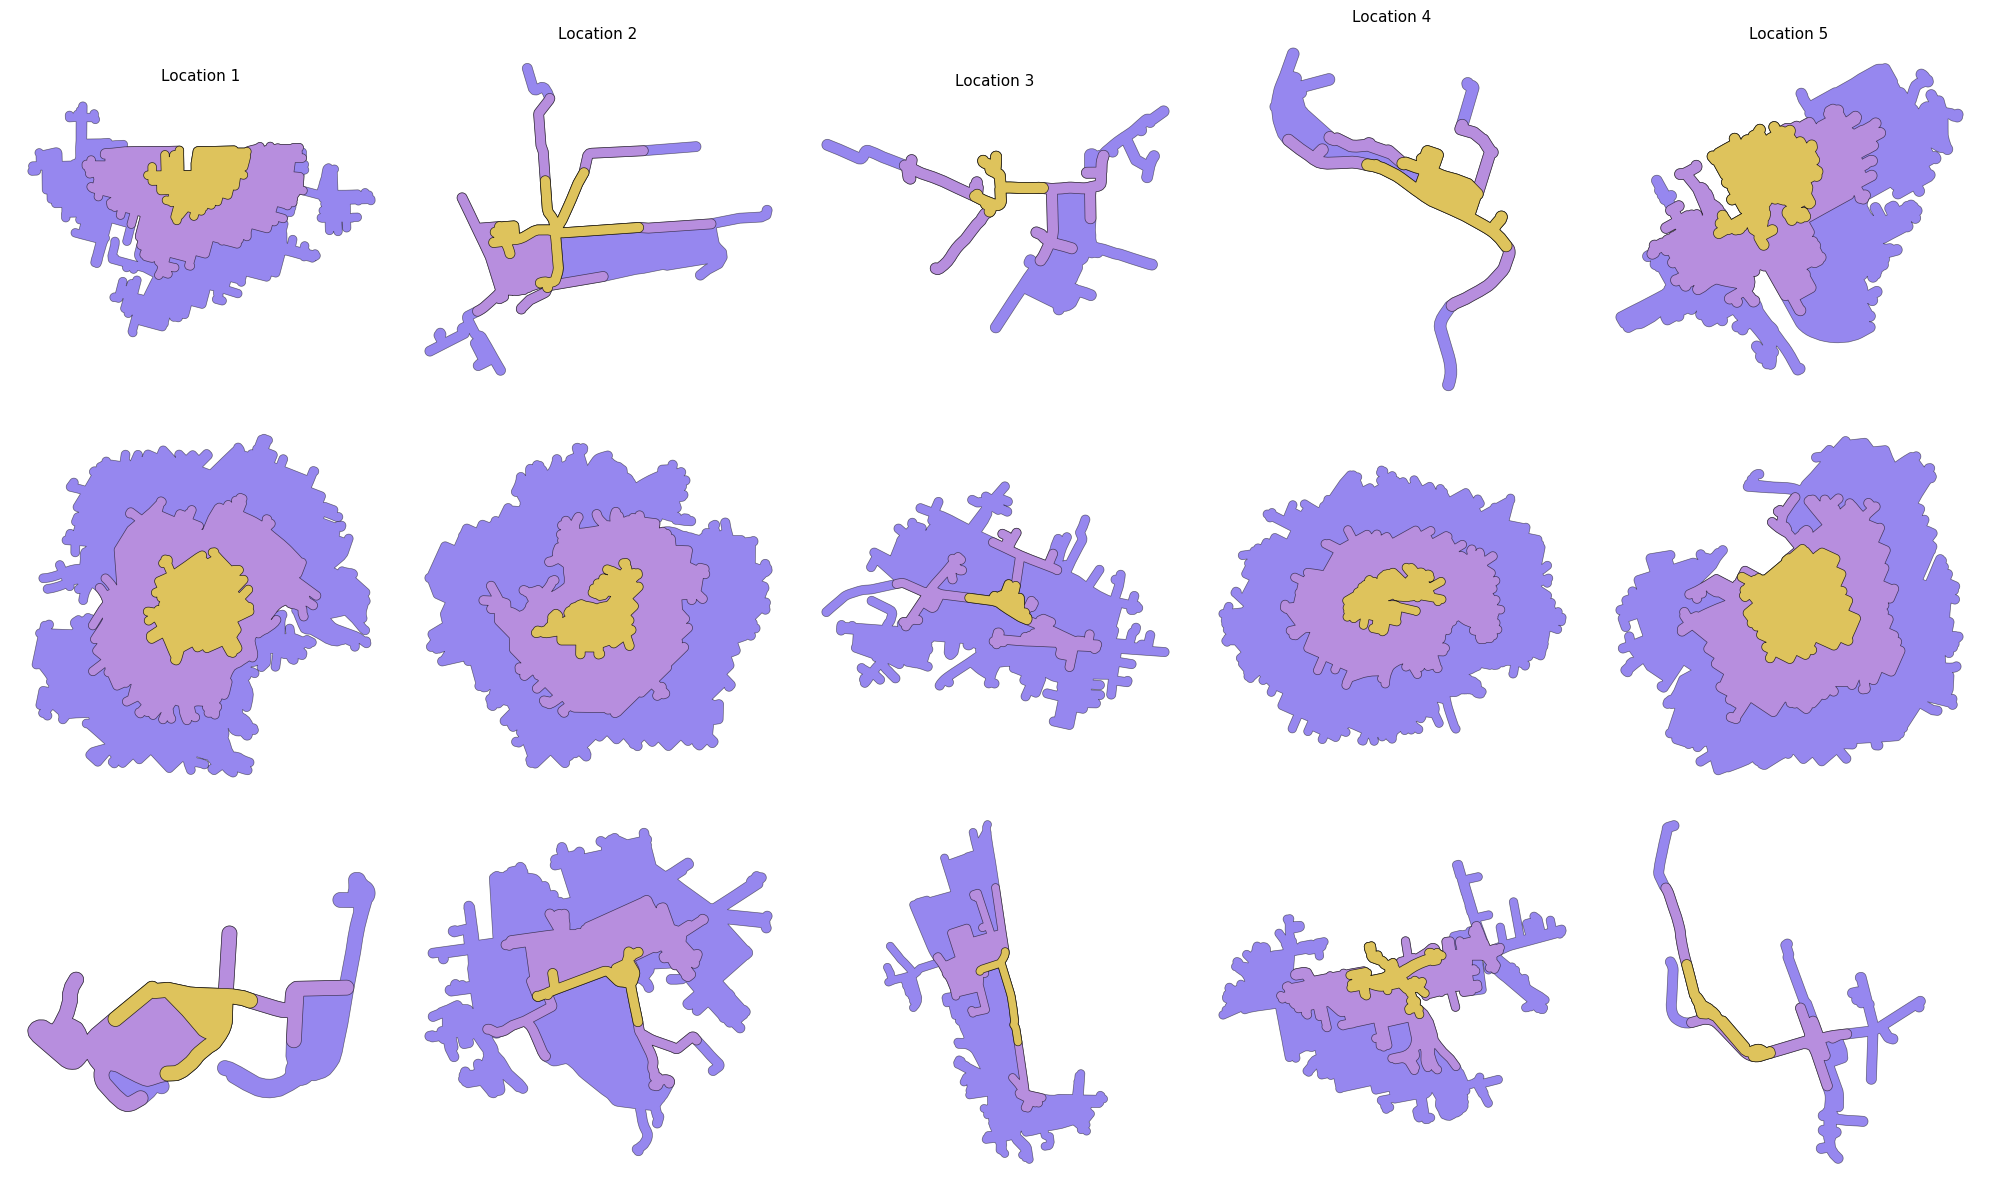

In [26]:
import matplotlib.pyplot as plt
import geopandas as gpd

titles = ["Amsterdam", "Athens", "Milan"]
city_names = ["amsterdam", "athens", "milan"]

n_rows = len(city_names)
n_cols = len(gdfs_iso["amsterdam"])  # number of sampled locations

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for i, (city_name, title) in enumerate(zip(city_names, titles)):
    gdf = gdfs_iso[city_name]

    for j in range(n_cols):
        ax = axes[i, j] if n_rows > 1 else axes[j]
        row = gdf.iloc[j]

        # 15 min in the back
        if row["geom_avg_time_15"] is not None:
            gpd.GeoSeries([row["geom_avg_time_15"]], crs=gdf.crs).plot(
                ax=ax, color="#2f10e0", edgecolor="black", linewidth=0.5, alpha=0.5
            )

        # 10 min in the middle
        if row["geom_avg_time_10"] is not None:
            gpd.GeoSeries([row["geom_avg_time_10"]], crs=gdf.crs).plot(
                ax=ax, color="#CE94D3", edgecolor="black", linewidth=0.5, alpha=0.6
            )

        # 5 min on top
        if row["geom_avg_time_5"] is not None:
            gpd.GeoSeries([row["geom_avg_time_5"]], crs=gdf.crs).plot(
                ax=ax, color="#E8D13C", edgecolor="black", linewidth=0.5, alpha=0.8
            )

        # titles
        if i == 0:
            ax.set_title(f"Location {j+1}", fontsize=11)

        if j == 0:
            ax.set_ylabel(title, fontsize=12)

        ax.axis("off")

plt.tight_layout()
plt.show()